In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# df1 = pd.read_csv('/kaggle/input/depressive-bangla/tweet_depressive_nondepressive_labels.txt',names =['label'])
# df2 = pd.read_csv('/kaggle/input/depressive-bangla/tweet_depressive_nondepressive_text.txt', delimiter='\t', header=None,names =['text'])

In [3]:
df_test = pd.read_csv('/kaggle/input/depressive-original/test_df_depressive.csv')
df_train = pd.read_csv('/kaggle/input/depressive-original/train_df_depressive.csv')

In [4]:
!wget https://www.easynepalityping.com/resource/font/bangla/06-nikosh-bangla-font.zip

--2026-04-19 16:19:05--  https://www.easynepalityping.com/resource/font/bangla/06-nikosh-bangla-font.zip
Resolving www.easynepalityping.com (www.easynepalityping.com)... 172.67.168.155, 104.21.26.239, 2606:4700:3031::6815:1aef, ...
Connecting to www.easynepalityping.com (www.easynepalityping.com)|172.67.168.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 317905 (310K) [application/zip]
Saving to: '06-nikosh-bangla-font.zip'

06-nikosh-bangla-fo 100%[===================>] 310.45K  --.-KB/s    in 0.009s  

2026-04-19 16:19:06 (31.9 MB/s) - '06-nikosh-bangla-font.zip' saved [317905/317905]



In [5]:
!unzip 06-nikosh-bangla-font.zip

Archive:  06-nikosh-bangla-font.zip
  inflating: Nikosh.ttf              


In [6]:
! pip install bnlp_toolkit==3.3.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.3 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171033 sha256=86903bcbf5d9c0f1b41d1759e70af264bd10751ee5b02e8fa0d86adb49567582
  Stored in directory: /root/.cache/pip/wheels/31/8a/8c/315c9e5d7773f74b33d5ed33f075b49c6eaeb7cedbb86e2cf8
Successfully built emoji
  Attempting uninstall: emoji
    Found existing installation: emoji 2.11.0
    Uninstalling emoji-2.11.0:
      Successfully uninstalled emoji-2.11.0


In [7]:
from bnlp import BasicTokenizer
from bnlp.corpus import stopwords, punctuations, letters, digits

btokenizer = BasicTokenizer()

def clean_text(text):
    tokens = btokenizer.tokenize(text)
    filtered = []
    for i in tokens:
        if i in stopwords:
            continue
    
        if i in punctuations + '‘' + '’':
            continue
    
        filtered.append(i)
    
    return " ".join(filtered)

print("********** Before ***************")
text = df_train.iloc[1]['text']
print(text)
print("\n********** After ***************")
print(clean_text(text))

********** Before ***************
গুনাহের যদি কোন গন্ধ থাকতো তাহলে আমরা কেউ পাশাপাশি বসতেও পারতাম না । পাশাপাশি বসা তো দূরে থাক আমরা কয়েশ মেইল দূরে যেয়েও গন্ধমুক্ত থাকতে পারতাম না । আজকাল গুনাহের কাজ গুলো আমাদের কাছে খুব সহজ আর অভ্যাসে পরিণত হওয়া কাজ 

********** After ***************
গুনাহের গন্ধ থাকতো পাশাপাশি বসতেও পারতাম পাশাপাশি বসা দূরে থাক কয়েশ মেইল দূরে যেয়েও গন্ধমুক্ত থাকতে পারতাম আজকাল গুনাহের গুলো সহজ অভ্যাসে পরিণত


In [8]:
import string

def clean_text(text):
    # Remove brackets and punctuations
    text = text.strip('[]')  # Remove leading/trailing brackets
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuations
    return text

def clean_dataframe(df):
    # Apply clean_text function to the 'text' column of the DataFrame
    df['text'] = df['text'].apply(clean_text)
    return df

cleaned_df_train = clean_dataframe(df_train)
cleaned_df_test = clean_dataframe(df_test)

In [9]:
df_train.label.value_counts()

label
non_depressive    2033
depressive         706
Name: count, dtype: int64

In [10]:
!pip install fasttext


In [11]:
from sklearn.model_selection import train_test_split
import fasttext

In [12]:
df_test.label.value_counts()

label
non_depressive    897
depressive        278
Name: count, dtype: int64

In [13]:
from imblearn.over_sampling import RandomOverSampler

In [14]:
# Separate the features and the target
X = df_train['text'].values.reshape(-1, 1)  # Reshape is necessary to fit the oversampler
y = df_train['label']

# Initialize the RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Apply the RandomOverSampler to balance the classes
X_resampled, y_resampled = ros.fit_resample(X, y)

# Convert the resampled data back to a DataFrame
df_resampled = pd.DataFrame({
    'text': X_resampled.flatten(),  # Flatten to convert from 2D array to 1D
    'label': y_resampled
})

# Display the resampled dataframe
print(df_resampled)

                                                   text           label
0     কেউ আপনার সাথে সদাচারণ করলে তার জন্য দো আ আল্ল...  non_depressive
1     গুনাহের যদি কোন গন্ধ থাকতো তাহলে আমরা কেউ পাশা...  non_depressive
2     সেদিন এক মধ্য বয়স্ক পাগলীকে দেখেছিলাম রাস্তায...      depressive
3     সম্মান  শ্রদ্ধা  ভালোবাসা অনেকটা আয়নার মতো তু...  non_depressive
4     মাদক মামলায় বন্দীদের জন্য বিশেষ জেল করার প্রস...  non_depressive
...                                                 ...             ...
4061  মনের পার্লামেন্টে আজ স্পিকার নেই । মনের জনসভায...      depressive
4062  কবি নজরুল এইযে কবি  চ্যাংড়া ছেলে  লিখছো কি সব...      depressive
4063  আমি অনেকদিন ধরেই বলে আসছি যে বিজেপি আর সংঘী রা...      depressive
4064  আমার মেয়ের জন্য একটি সুন্দর নাম দিন । অর্থসহ ...      depressive
4065  বর্তমান পৃথিবীতে আমার কাছে মনে হয় দুইটা জিনিস...      depressive

[4066 rows x 2 columns]


In [15]:
df_resampled.label.value_counts()

label
non_depressive    2033
depressive        2033
Name: count, dtype: int64

In [16]:
X_train = df_resampled['text']
y_train = df_resampled['label']

X_test = df_test['text']
y_test = df_test['label']

In [17]:
# Write training data
with open('train.txt', 'w', encoding='utf-8') as f:
    for (text), label in zip(X_train.values, y_train):
        f.write(f'__label__{label} {text}\n')

# Write testing data
with open('test.txt', 'w', encoding='utf-8') as f:
    for (text), label in zip(X_test.values, y_test):
        f.write(f'__label__{label} {text}\n')

In [18]:
import fasttext
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def train_and_evaluate_model(lr, epoch, wordNgrams, loss, dim):
    global best_accuracy
    global best_model
    model = fasttext.train_supervised(
        input='train.txt',
        lr=lr,
        epoch=epoch,
        wordNgrams=wordNgrams,
        dim = dim,
        loss = loss,
        thread=4 #Adjust the number threads based on your system
      
    )

     # Evaluate the model on the validation set
    result = model.test('test.txt')
    accuracy = result[1] # Accuracy is the second element in the result tupl
    precision = result[2]
    
    print(f'For lr={lr}, epochs={epoch}, wordNgrams={wordNgrams}, dim={dim}, loss={loss}:')

    print(f'Accuracy: {accuracy}')
    print(f'Precision: {precision}')
    
    if accuracy>best_accuracy:
        best_accuracy = accuracy
        best_model = model
    

best_model = -1
best_accuracy = -1

# Define a grid of hyperparameter values to search
learning_rates = [0.1]
epochs = [200]
word_ngrams_values = [3]
losses = ['ns']
dims = [10]

# Iterate through the hyperparameter grid and train/evaluate the model
for lr in learning_rates:
    for epoch in epochs:
        for word_ngrams in word_ngrams_values:
            for loss in losses:
                for dim in dims:
                    train_and_evaluate_model(lr, epoch, word_ngrams,loss,dim)
   

Read 0M words
Number of words:  9449
Number of labels: 2
Progress:  97.0% words/sec/thread: 1886574 lr:  0.003003 avg.loss:  0.476559 ETA:   0h 0m 0s

For lr=0.1, epochs=200, wordNgrams=3, dim=10, loss=ns:
Accuracy: 0.828936170212766
Precision: 0.828936170212766


Progress: 100.0% words/sec/thread: 1872938 lr:  0.000000 avg.loss:  0.474975 ETA:   0h 0m 0s


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

Accuracy: 0.828936170212766
                precision    recall  f1-score   support

    depressive       0.64      0.65      0.64       278
non_depressive       0.89      0.88      0.89       897

      accuracy                           0.83      1175
     macro avg       0.76      0.77      0.77      1175
  weighted avg       0.83      0.83      0.83      1175



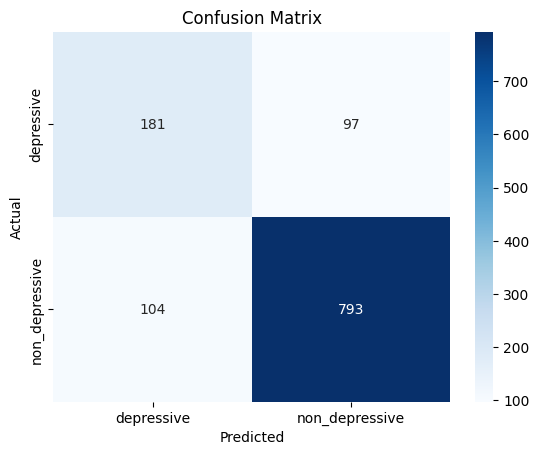

In [20]:
import seaborn as sns

model = best_model
# Predict on the test set
y_pred = model.predict([f' {text}' for (text) in X_test.values])[0]
#print(type(y_pred))

processed_labels = []
for x in y_pred:
    x = str(x)
    x = x.replace('__label__', '')
    processed_labels.append(x)
y_pred = processed_labels


extracted_labels = [label[2:-2] for label in y_pred]
y_pred = extracted_labels


# # # Convert labels to integers for sklearn metrics
# label_mapping = {'': 0, 'auth': 1}

# y_test_int = [label_mapping[label] for label in y_test]
# y_pred_int= [label_mapping[label] for label in y_pred]


# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Print classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
labels = np.unique(y_test)

# Create a heatmap with seaborn
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show the plot
plt.show()


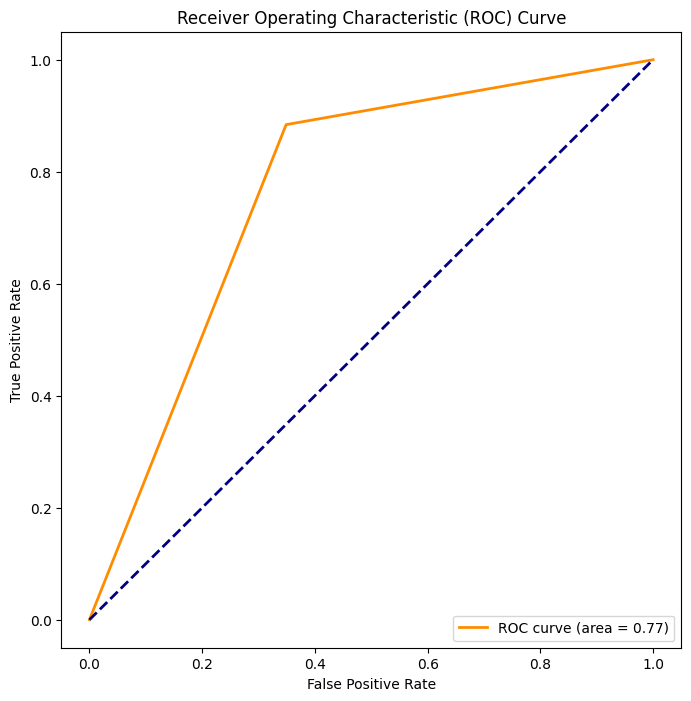

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Assuming 'model' is your best model and 'X_test' and 'y_test' are your test data
y_score = model.predict([f' {text}' for text in X_test.values])[0]

# Process labels
processed_labels = [str(x).replace('__label__', '')[2:-2] for x in y_score]

# Convert labels to integers for sklearn metrics
label_mapping = {'depressive': 0, 'non_depressive': 1}
y_test_int = [label_mapping[label] for label in y_test]
y_score_bin = label_binarize(processed_labels, classes=['depressive', 'non_depressive'])

# Check if y_score_bin is 1D (binary classification) and expand dimensions if necessary
if y_score_bin.ndim == 1:
    y_score_bin = y_score_bin.reshape(-1, 1)
    
# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test_int, y_score_bin[:, 0])  # Use the first column for binary classification
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig('roc_1.png')
plt.show()